Dataset shape: (569, 30)

Naive Bayes Accuracy: 0.9736842105263158

Naive Bayes Confusion Matrix:
 [[40  3]
 [ 0 71]]

Naive Bayes Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.93      0.96        43
           1       0.96      1.00      0.98        71

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



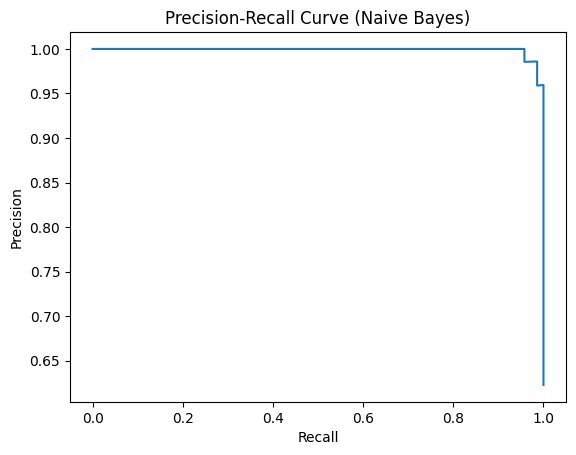


Decision Tree Accuracy: 0.9473684210526315

Decision Tree Confusion Matrix:
 [[40  3]
 [ 3 68]]

Decision Tree Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



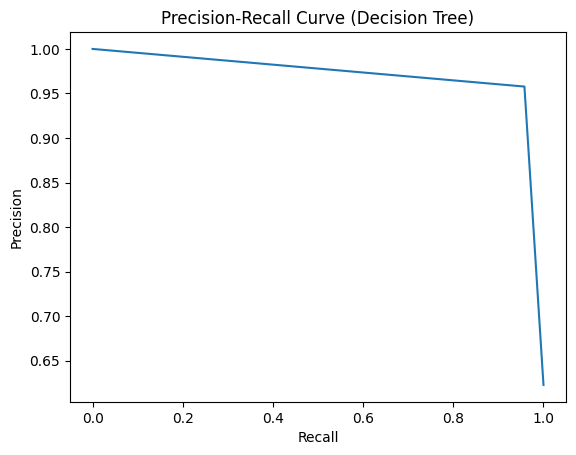

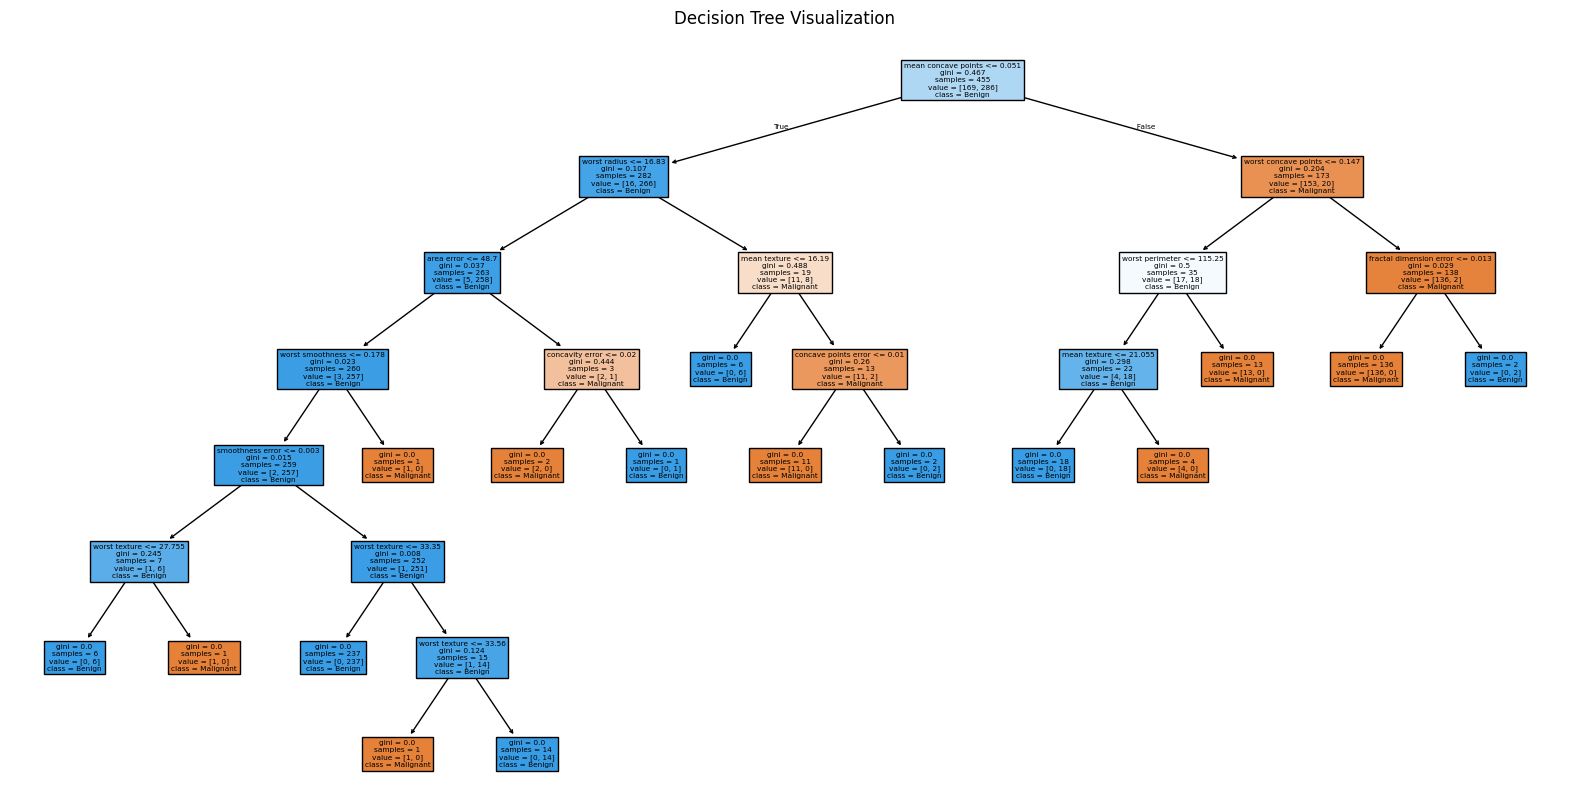

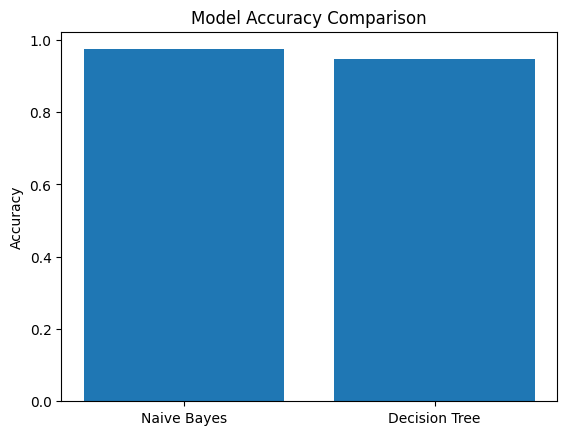

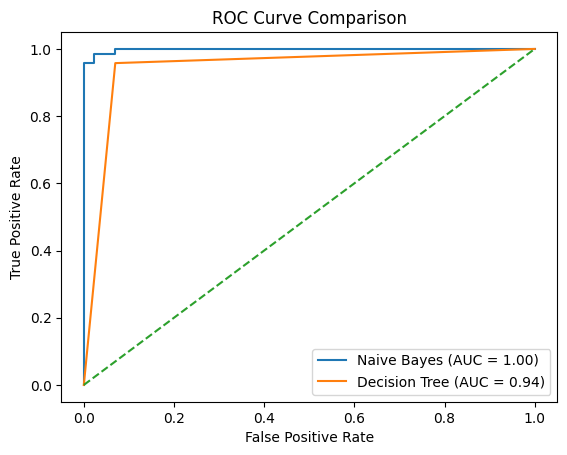

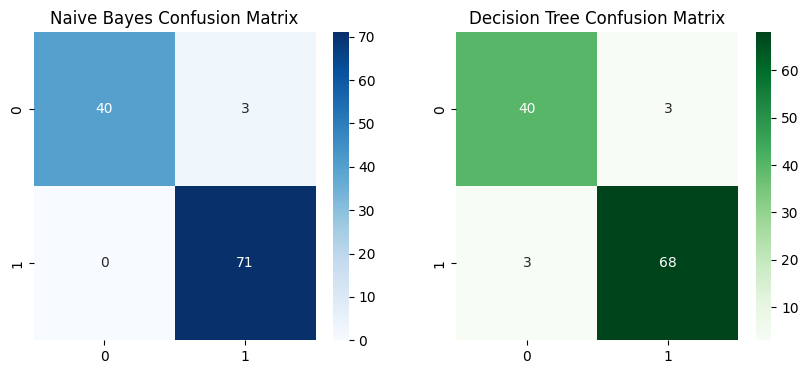

In [ ]:
# ================================
# Import Libraries
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve,
    auc
)

# ================================
# Load Dataset
# ================================
data = load_breast_cancer()

X = data.data
y = data.target
feature_names = data.feature_names

print("Dataset shape:", X.shape)

# ================================
# Train Test Split
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ================================
# Naive Bayes Model
# ================================
nb = GaussianNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)
y_prob_nb = nb.predict_proba(X_test)[:,1]

# Accuracy
nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("\nNaive Bayes Accuracy:", nb_accuracy)

# Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)

print("\nNaive Bayes Confusion Matrix:\n", cm_nb)

# Classification Report
print("\nNaive Bayes Classification Report:\n")
print(classification_report(y_test, y_pred_nb))

# ================================
# Precision Recall Curve
# ================================
precision_nb, recall_nb, _ = precision_recall_curve(y_test, y_prob_nb)

plt.figure()
plt.plot(recall_nb, precision_nb)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Naive Bayes)")
plt.show()
# .............................................................
# ================================
# Decision Tree Model
# ================================
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:,1]

# Accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("\nDecision Tree Accuracy:", dt_accuracy)

# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

print("\nDecision Tree Confusion Matrix:\n", cm_dt)

# Classification Report
print("\nDecision Tree Classification Report:\n")
print(classification_report(y_test, y_pred_dt))

# ================================
# Precision Recall Curve
# ================================
precision_dt, recall_dt, _ = precision_recall_curve(y_test, y_prob_dt)

plt.figure()
plt.plot(recall_dt, precision_dt)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Decision Tree)")
plt.show()

# ================================
# Decision Tree Visualization
# ================================
plt.figure(figsize=(20,10))

plot_tree(
    dt,
    feature_names=feature_names,
    class_names=["Malignant","Benign"],
    filled=True
)

plt.title("Decision Tree Visualization")
plt.show()
# ...........................................................................................
# ================================
# Comparison - Accuracy Bar Chart
# ================================
models = ["Naive Bayes", "Decision Tree"]
accuracies = [nb_accuracy, dt_accuracy]

plt.figure()
plt.bar(models, accuracies)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()

# ================================
# ROC Curve Comparison
# ================================
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)

roc_auc_nb = auc(fpr_nb, tpr_nb)
roc_auc_dt = auc(fpr_dt, tpr_dt)

plt.figure()

plt.plot(fpr_nb, tpr_nb, label="Naive Bayes (AUC = %0.2f)" % roc_auc_nb)
plt.plot(fpr_dt, tpr_dt, label="Decision Tree (AUC = %0.2f)" % roc_auc_dt)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()

# ================================
# Confusion Matrix Heatmaps
# ================================
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.heatmap(cm_nb, annot=True, cmap="Blues", fmt='d')
plt.title("Naive Bayes Confusion Matrix")

plt.subplot(1,2,2)
sns.heatmap(cm_dt, annot=True, cmap="Greens", fmt='d')
plt.title("Decision Tree Confusion Matrix")

plt.show()